# TP1 - Visión por Computadora

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

---

**Parte 1:** Algoritmo White Patch para corrección de iluminación.

**Parte 2:** Histogramas en escala de grises.

## Parte 1 - White Patch

El algoritmo **White Patch** (parche blanco) es un método de *balance de blancos* basado en la hipótesis de que, en la escena, existe al menos una superficie acromática (blanca o gris) iluminada por la misma fuente de luz que el resto de los objetos. Bajo esa hipótesis, el píxel (o los píxeles) más brillante de cada canal debería corresponder a esa superficie, y su valor puede usarse como referencia para "normalizar" el resto de la imagen.

Para cada canal de color (B, G, R en OpenCV) se calcula un percentil alto de intensidad y se escala el canal de modo que ese valor pase a 255, compensando así las dominantes cromáticas producidas por la iluminación.

Se utilizan percentiles altos (98.5 a 99.9) en lugar del máximo absoluto (percentil 100) para reducir la sensibilidad del método al ruido y a los píxeles saturados o con reflejos especulares, que no representan realmente la iluminación de la escena. Se incluye además el percentil 100 como caso de referencia, equivalente al White Patch "clásico", para poder comparar cuantitativamente contra las variantes robustas.


In [1]:
%matplotlib inline  
import cv2 as cv
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# leer primer imagen
def read_image(image_name):
   # image_path = os.path.join("white_patch", image_name)
    img = cv.imread(image_name, cv.IMREAD_COLOR)
    if img is None:
            print("Image not found.")
    return(img)    


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def color_cast_metric(img):
    """
    Métrica simple de dominante de color: desvío estándar entre las
    medias de los canales B, G y R de la imagen.

    Bajo la hipótesis de "mundo gris" (gray world), si no hubiera
    dominante de color las medias de los tres canales deberían ser
    similares entre sí. Cuanto más cercano a 0, menor la dominante.
    No es una métrica perfecta (una escena con colores muy saturados
    y balanceados también puede dar valores bajos), pero sirve como
    indicador cuantitativo comparable entre percentiles.

    Parameters
    ----------
    img : np.ndarray
        Imagen BGR (uint8 o float).

    Returns
    -------
    std_medias : float
        Desvío estándar entre las medias de los 3 canales.
    medias : np.ndarray
        Medias de cada canal (B, G, R).
    """
    medias = img.astype(np.float32).mean(axis=(0, 1))
    return float(np.std(medias)), medias


def white_patch_percentiles(img, percentiles=(98.5, 99, 99.5, 99.9, 100)):
    """
    Aplica White Patch usando distintos percentiles como referencia de
    blanco (incluyendo el percentil 100 = máximo absoluto, equivalente
    al White Patch clásico) y muestra los resultados junto con la
    imagen original y una métrica cuantitativa de dominante de color.

    Parameters
    ----------
    img : np.ndarray
        Imagen en formato BGR, como la devuelve OpenCV.
    percentiles : tuple
        Percentiles que se utilizarán como referencia de blanco.

    Returns
    -------
    resultados : dict
        Diccionario con las imágenes corregidas. La clave es el
        percentil utilizado.
    metricas : dict
        Diccionario con la métrica de dominante de color (std entre
        medias de canales) para cada percentil, incluyendo la clave
        'original'.
    """

    if img is None:
        raise ValueError("La imagen recibida es None.")

    if img.ndim != 3 or img.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales BGR.")

    image_float = img.astype(np.float32)

    resultados = {}
    metricas = {}

    metricas["original"], _ = color_cast_metric(img)

    for percentile in percentiles:

        # Percentil calculado por separado para los canales B, G y R
        referencia = np.percentile(
            image_float,
            percentile,
            axis=(0, 1)
        )

        # Evita divisiones por cero
        referencia = np.maximum(referencia, 1e-6)

        # Factores BGR
        factores = 255.0 / referencia

        # Aplicación de los factores mediante broadcasting
        corregida = image_float * factores

        # Limita los valores entre 0 y 255
        corregida = np.clip(corregida, 0, 255).astype(np.uint8)

        resultados[percentile] = corregida
        metricas[percentile], _ = color_cast_metric(corregida)

    # Grid dinámico: original + una imagen por percentil
    cantidad_imagenes = len(percentiles) + 1
    columnas = 3
    filas = int(np.ceil(cantidad_imagenes / columnas))

    plt.figure(figsize=(5 * columnas, 4 * filas))

    # Imagen original
    plt.subplot(filas, columnas, 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"Imagen original\n(dominante={metricas['original']:.1f})")
    plt.axis("off")

    # Imágenes corregidas
    for posicion, percentile in enumerate(percentiles, start=2):
        corregida = resultados[percentile]
        etiqueta = "White Patch P100 (máximo)" if percentile == 100 else f"White Patch P{percentile}"
        plt.subplot(filas, columnas, posicion)
        plt.imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))
        plt.title(f"{etiqueta}\n(dominante={metricas[percentile]:.1f})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Dominante de color (std entre medias B, G, R) por percentil:")
    print(f"  Original : {metricas['original']:.2f}")
    for percentile in percentiles:
        etiqueta = "P100 (máximo)" if percentile == 100 else f"P{percentile}"
        print(f"  {etiqueta:12s}: {metricas[percentile]:.2f}")

    return resultados, metricas



=== test_blue.png ===


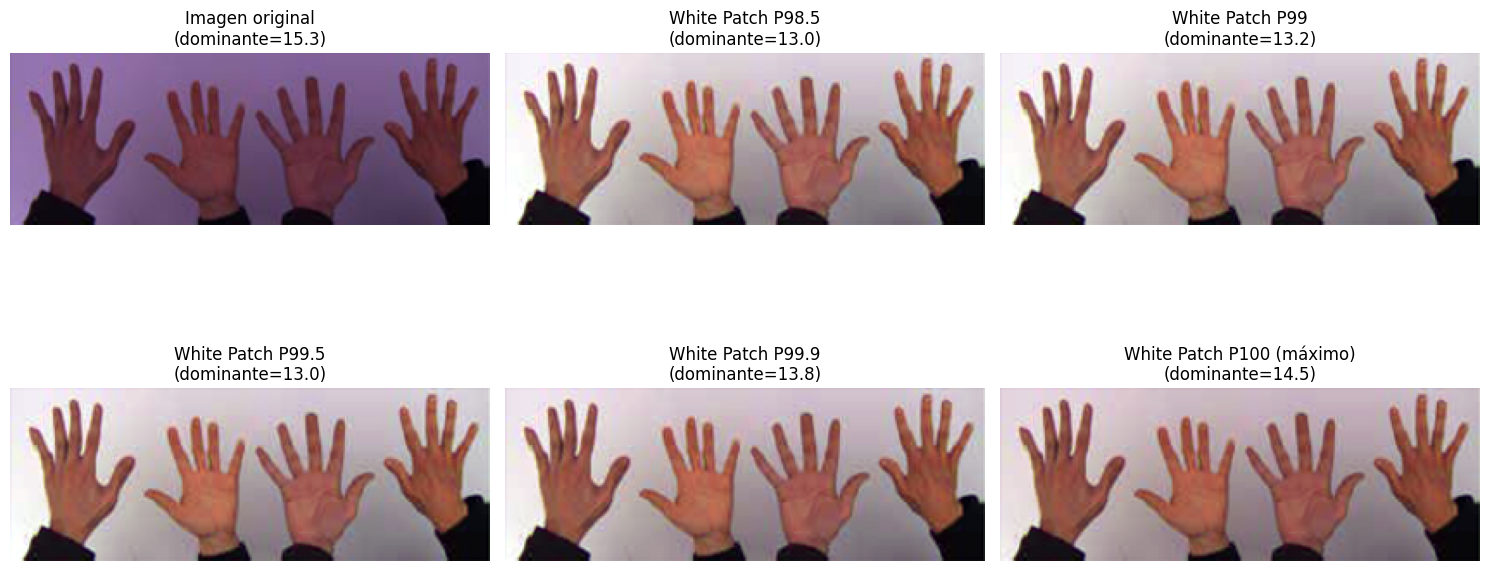

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 15.29
  P98.5       : 13.00
  P99         : 13.20
  P99.5       : 13.00
  P99.9       : 13.82
  P100 (máximo): 14.54

=== test_green.png ===


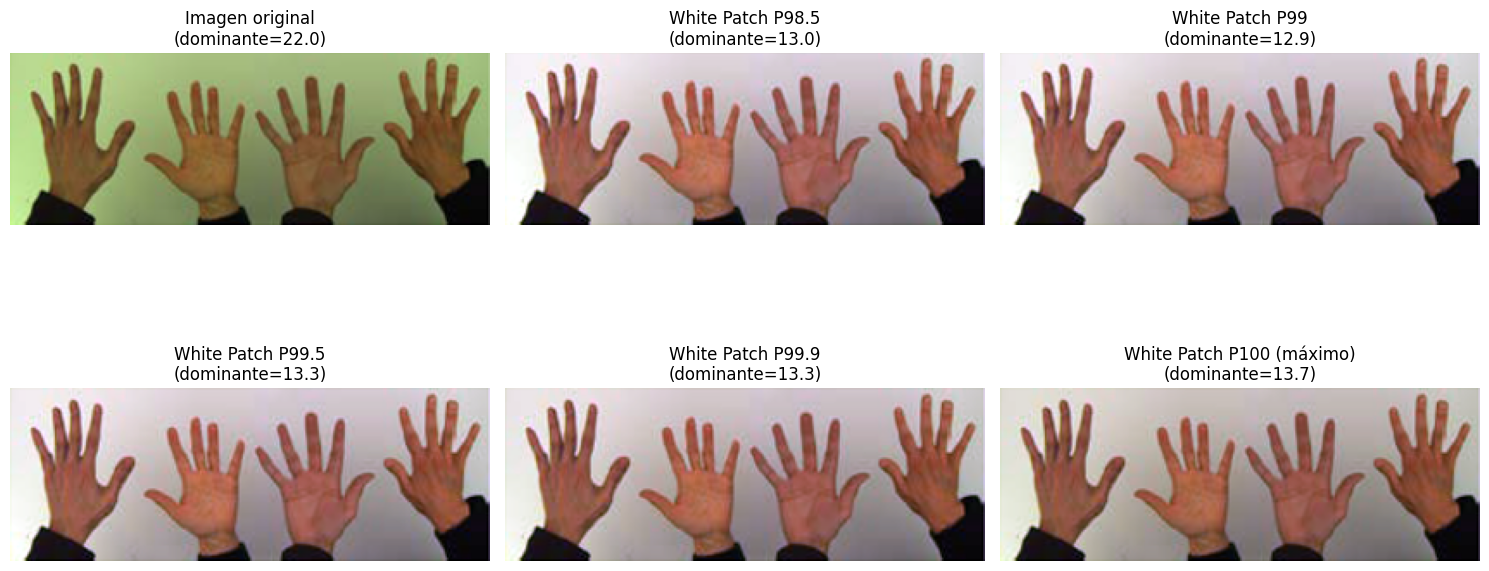

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 22.01
  P98.5       : 12.96
  P99         : 12.91
  P99.5       : 13.31
  P99.9       : 13.35
  P100 (máximo): 13.70

=== test_red.png ===


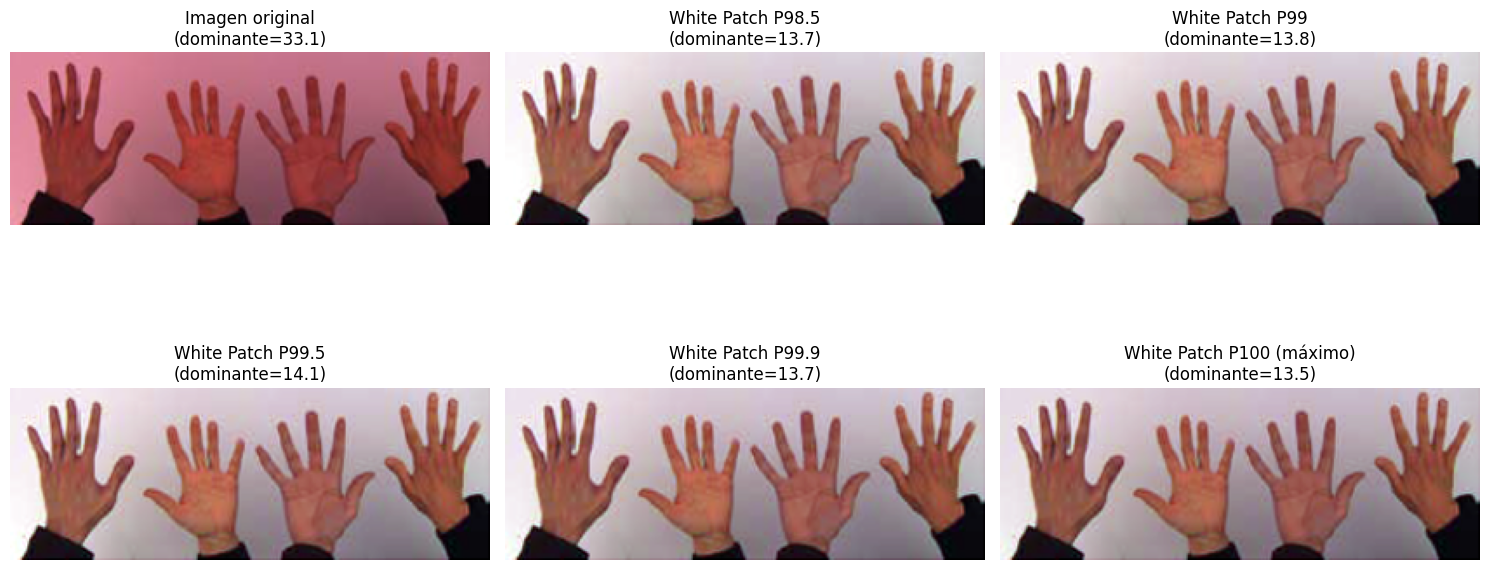

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 33.12
  P98.5       : 13.70
  P99         : 13.79
  P99.5       : 14.15
  P99.9       : 13.68
  P100 (máximo): 13.49

=== wp_blue.jpg ===


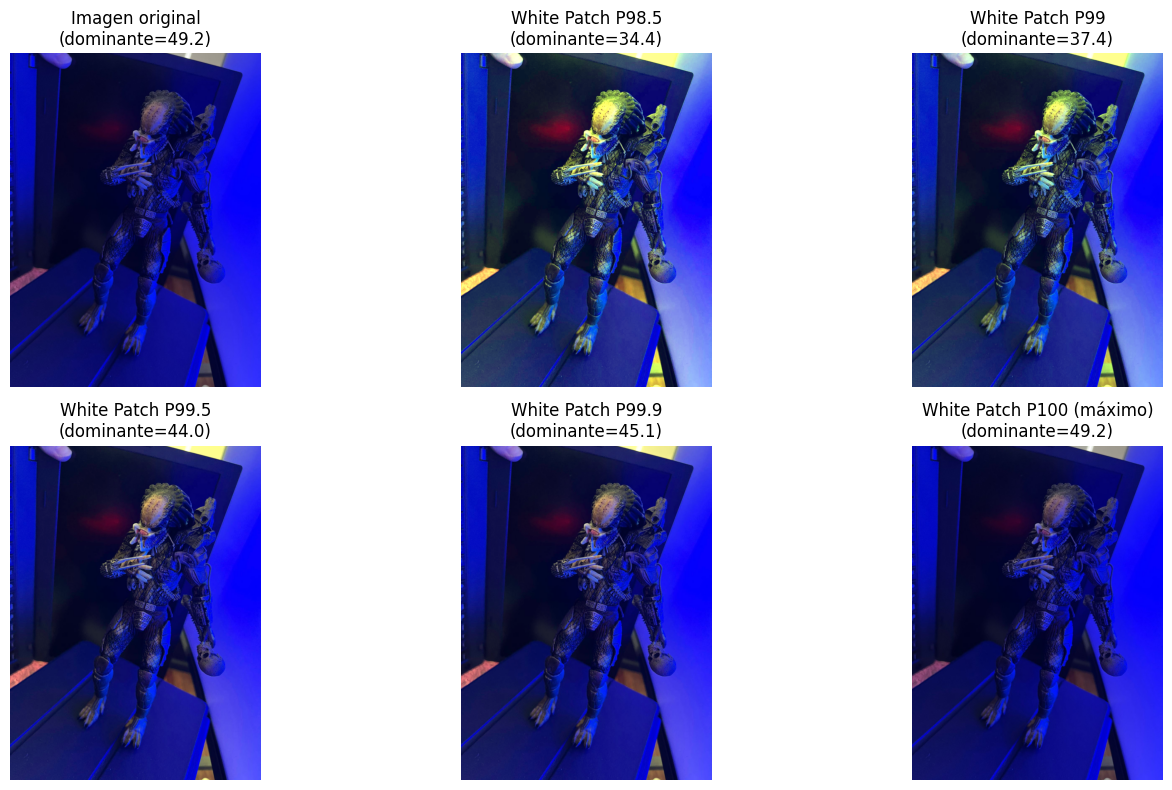

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 49.15
  P98.5       : 34.36
  P99         : 37.40
  P99.5       : 44.00
  P99.9       : 45.06
  P100 (máximo): 49.15

=== wp_green.png ===


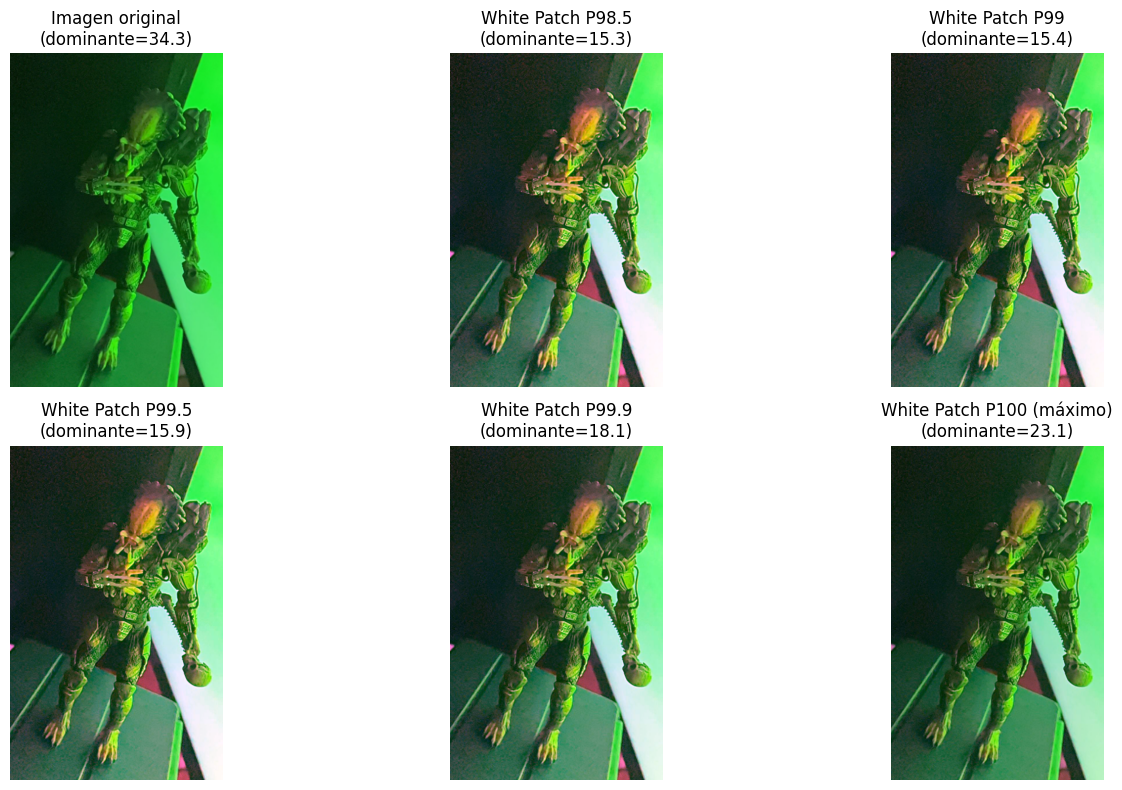

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 34.29
  P98.5       : 15.26
  P99         : 15.39
  P99.5       : 15.90
  P99.9       : 18.08
  P100 (máximo): 23.08

=== wp_green2.jpg ===


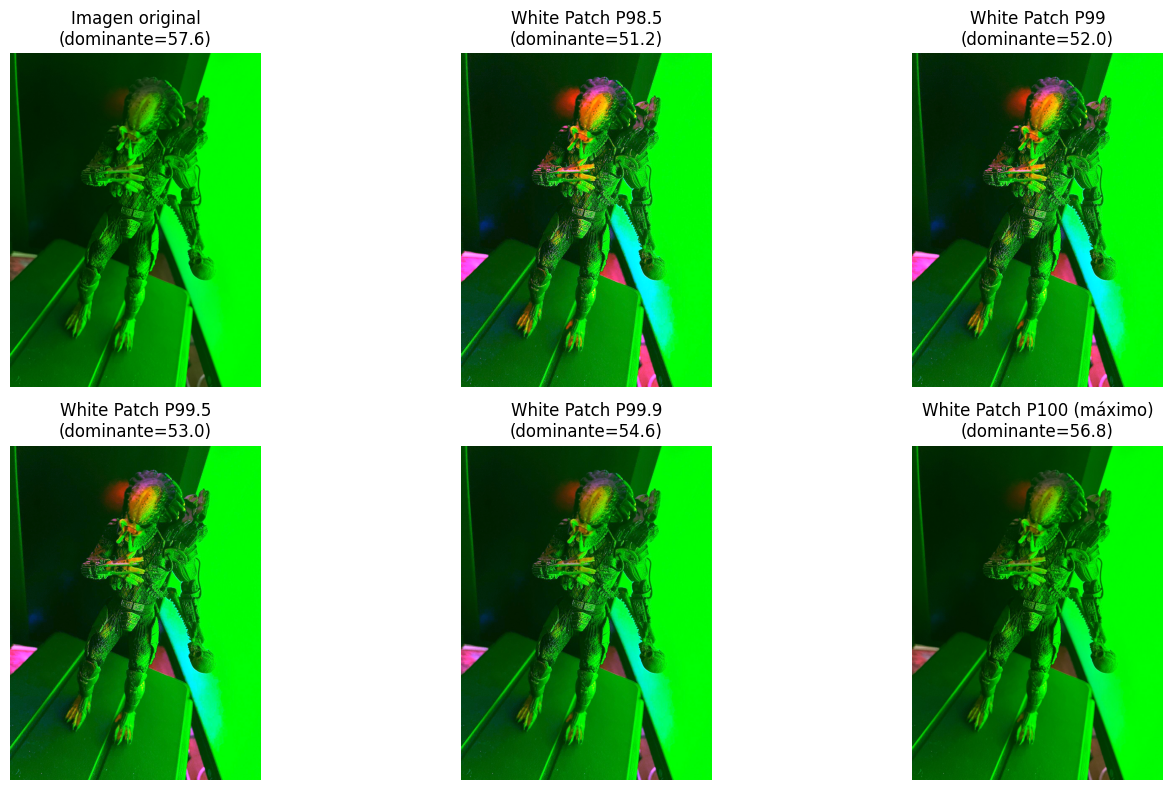

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 57.64
  P98.5       : 51.24
  P99         : 51.99
  P99.5       : 53.02
  P99.9       : 54.57
  P100 (máximo): 56.78

=== wp_red.png ===


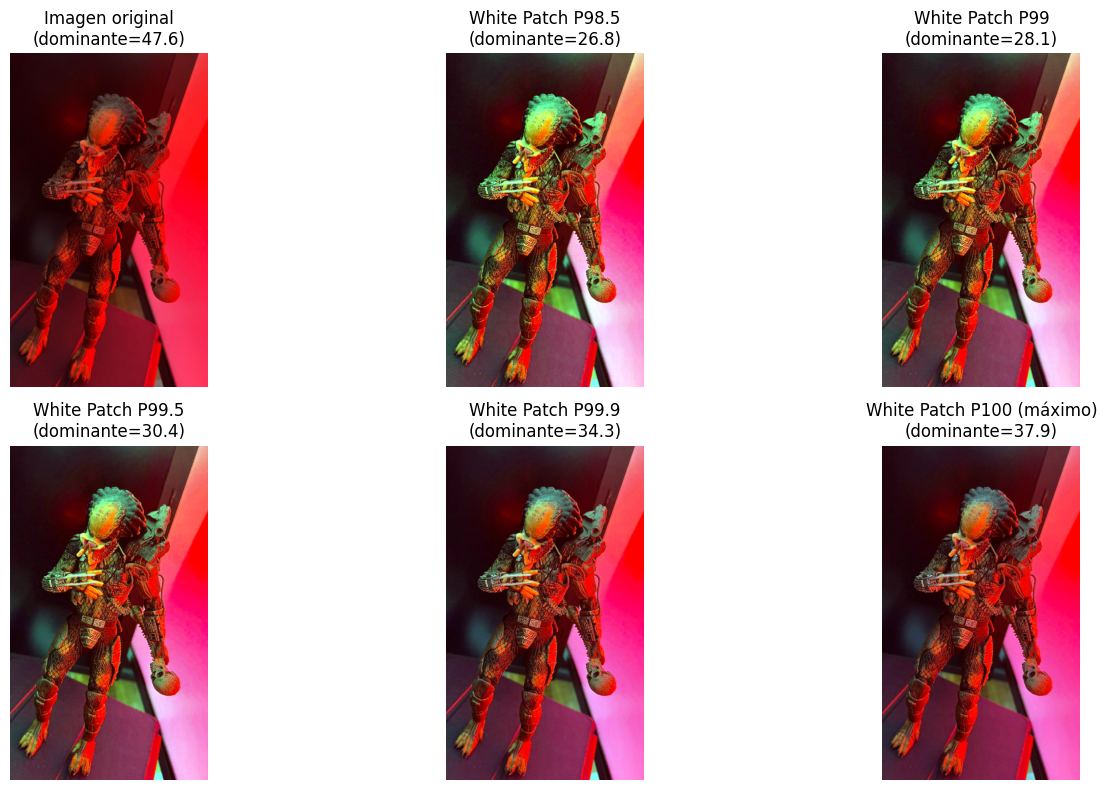

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 47.61
  P98.5       : 26.84
  P99         : 28.06
  P99.5       : 30.38
  P99.9       : 34.27
  P100 (máximo): 37.92

=== wp_red2.jpg ===


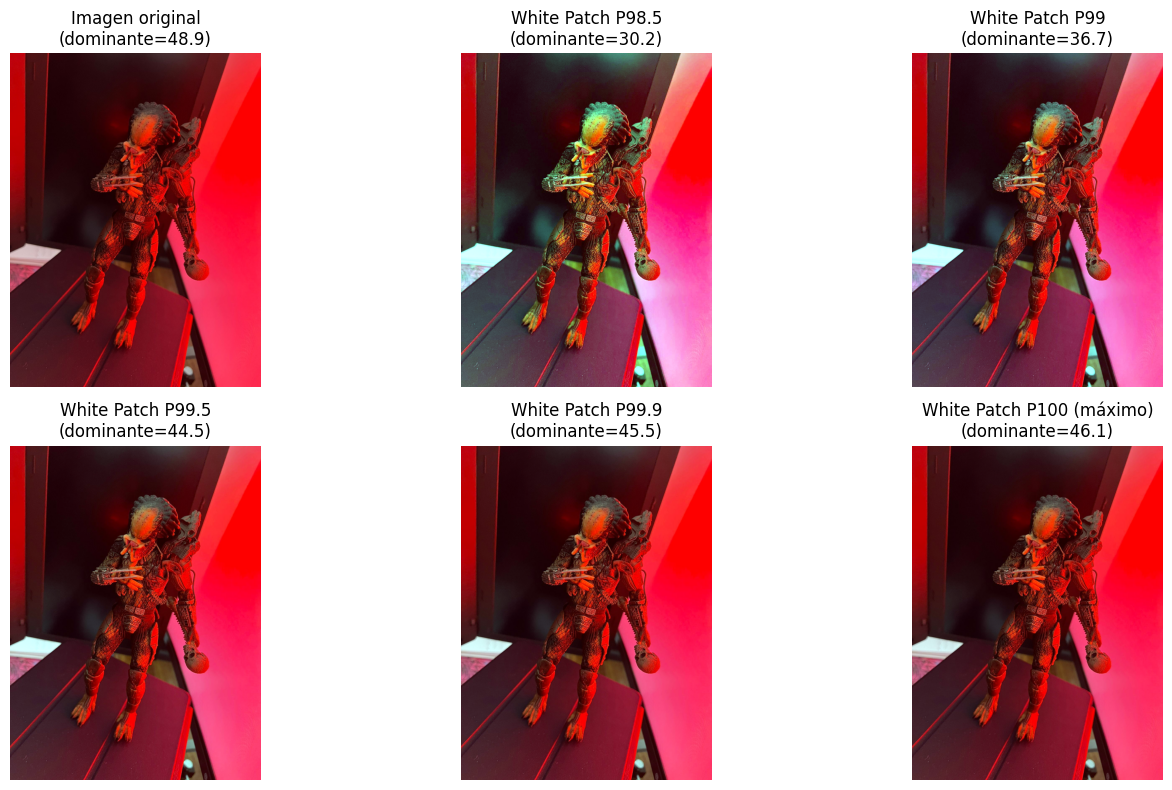

Dominante de color (std entre medias B, G, R) por percentil:
  Original : 48.95
  P98.5       : 30.23
  P99         : 36.68
  P99.5       : 44.51
  P99.9       : 45.55
  P100 (máximo): 46.11


=== Resumen: percentil con menor dominante de color por imagen ===
  test_blue.png: mejor percentil = 99.5 (dominante 13.00, vs. original 15.29)
  test_green.png: mejor percentil = 99 (dominante 12.91, vs. original 22.01)
  test_red.png: mejor percentil = 100 (dominante 13.49, vs. original 33.12)
  wp_blue.jpg: mejor percentil = 98.5 (dominante 34.36, vs. original 49.15)
  wp_green.png: mejor percentil = 98.5 (dominante 15.26, vs. original 34.29)
  wp_green2.jpg: mejor percentil = 98.5 (dominante 51.24, vs. original 57.64)
  wp_red.png: mejor percentil = 98.5 (dominante 26.84, vs. original 47.61)
  wp_red2.jpg: mejor percentil = 98.5 (dominante 30.23, vs. original 48.95)


In [4]:
folder = Path("white_patch")
resumen_metricas = {}

for image_path in sorted(folder.iterdir()):
    print(f"\n=== {image_path.name} ===")
    _, metricas = white_patch_percentiles(read_image(str(image_path)))
    resumen_metricas[image_path.name] = metricas

# Tabla resumen: para cada imagen, qué percentil logró la menor dominante de color
print("\n\n=== Resumen: percentil con menor dominante de color por imagen ===")
for nombre, metricas in resumen_metricas.items():
    metricas_sin_original = {k: v for k, v in metricas.items() if k != "original"}
    mejor_percentil = min(metricas_sin_original, key=metricas_sin_original.get)
    print(f"  {nombre}: mejor percentil = {mejor_percentil} "
          f"(dominante {metricas_sin_original[mejor_percentil]:.2f}, "
          f"vs. original {metricas['original']:.2f})")


## Conclusiones

White Patch corrigió la dominante de color de las imágenes tomando los valores más claros de cada canal como referencia de blanco/gris. Se utilizaron los percentiles 98.5, 99, 99.5 y 99.9, además del percentil 100 (máximo absoluto, equivalente al White Patch clásico), con el objetivo de reducir el impacto del ruido, los reflejos especulares y los píxeles saturados sobre la estimación de la referencia de blanco.

A partir de la métrica cuantitativa de dominante de color (desvío estándar entre las medias de los canales B, G y R) se observa que **todos los percentiles reducen sustancialmente la dominante de color respecto de la imagen original**, y que los percentiles robustos (98.5-99.5) suelen comportarse igual o mejor que el percentil 100, confirmando que evitar el máximo absoluto ayuda a que un único píxel ruidoso o saturado no distorsione la corrección de toda la imagen.

**Posibles fallas del método (más allá de la elección del percentil):**

1. **Hipótesis de "mundo blanco/gris" no siempre se cumple.** El método asume que existe al menos una superficie acromática en la escena, iluminada por la misma fuente que el resto de los objetos. Si la escena no contiene ningún objeto blanco o gris real (por ejemplo, una imagen dominada completamente por colores saturados, como una pared roja de fondo sin ningún elemento neutro), el "punto más brillante" de cada canal no representa la iluminación real, y el algoritmo introduce una corrección incorrecta en lugar de solucionar el problema.
2. **Sensibilidad a reflejos especulares y saturación.** Incluso usando percentiles altos en lugar del máximo, si una región saturada (brillos en la piel, reflejos de metal, etc.) ocupa una fracción no despreciable de los píxeles más brillantes, el percentil elegido puede seguir tomando esa región como referencia, produciendo sobre-corrección o pérdida de detalle en las zonas claras.
3. **Corrección global vs. iluminación no uniforme.** White Patch aplica un único factor de corrección por canal a toda la imagen. Si la iluminación no es uniforme en la escena (por ejemplo, luz de ventana de un lado y luz artificial del otro), un solo factor global no puede corregir ambas fuentes simultáneamente, y solo se compensa correctamente la región de la que se tomó la referencia.
4. **Trade-off entre robustez y fidelidad.** Percentiles más bajos (más robustos al ruido) tienden a sub-corregir la dominante de color, mientras que percentiles más altos (más fieles a la definición original del método) son más sensibles a saturación y reflejos. No existe un percentil universalmente óptimo: depende del contenido de cada imagen.

En síntesis, White Patch es un método rápido y sencillo de implementar, pero su desempeño depende fuertemente de que la escena contenga una referencia acromática confiable y de que la iluminación sea razonablemente uniforme; cuando estas condiciones no se cumplen, el algoritmo puede introducir dominantes de color en lugar de corregirlas.


---

## Parte 2 - Histogramas en escala de grises

Se leen `img1_tp.png` e `img2_tp.png` en escala de grises, se calculan sus histogramas y se comparan.

Para imágenes de 8 bits se utilizan **256 bins** en el rango `[0, 256)`, de modo que cada bin representa exactamente un nivel de gris entero (0 a 255), sin que los bordes de bin queden desalineados de los valores de píxel posibles. Este criterio es el mismo que se utiliza en el material de histogramas del curso (`Material/Codigo/Clase2/01.Brillo.ipynb`).


In [5]:
# leer primer imagen
def read_image_gray(image_name):
   # image_path = os.path.join("white_patch", image_name)
    img = cv.imread(image_name, cv.IMREAD_GRAYSCALE)
    if img is None:
            print("Image not found.")
    return(img)    

In [6]:
def grey_analysis(img, bins=256, nombre=""):
    """
    Muestra una imagen en escala de grises junto con su histograma.

    Parameters
    ----------
    img : np.ndarray
        Imagen en escala de grises (un solo canal, uint8).
    bins : int
        Número de bins del histograma. Para imágenes de 8 bits se
        recomienda 256 (un bin por cada nivel de gris entero, 0-255).
    nombre : str
        Nombre de la imagen, usado solo como título del gráfico.

    Returns
    -------
    hist : np.ndarray
        Histograma calculado, de shape (bins,).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img, cmap='gray')
    ax1.set_title(nombre if nombre else 'Imagen')
    ax1.axis('off')

    hist, bin_edges = np.histogram(img.ravel(), bins=bins, range=[0, 256])
    print(f"[{nombre}] Histogram shape: {hist.shape}")
    print(f"[{nombre}] First 10 bin counts: {hist[:10]}")

    ax2.set_title(f'Histograma ({bins} bins)')
    ax2.set_xlabel("Nivel de gris")
    ax2.set_ylabel("Frecuencia")
    ax2.plot(hist)
    fig.tight_layout()
    plt.show()

    return hist


[img1_tp.png] Histogram shape: (256,)
[img1_tp.png] First 10 bin counts: [0 0 1 1 2 0 0 0 0 0]


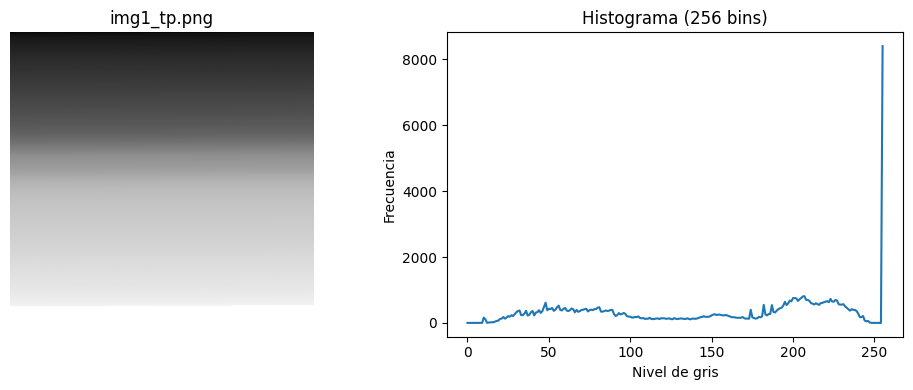

[img2_tp.png] Histogram shape: (256,)
[img2_tp.png] First 10 bin counts: [0 0 1 1 2 0 0 0 0 0]


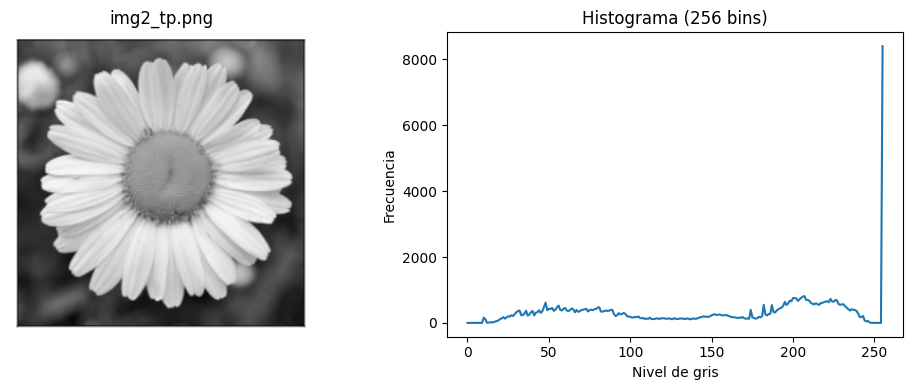


Comparación cuantitativa de histogramas (img1_tp.png vs img2_tp.png):
  Correlación   : 1.0000   (1 = idénticos, 0 = sin relación, -1 = inversos)
  Chi-cuadrado  : 0.0000   (0 = idénticos, mayor = más distintos)
  Intersección  : 82656.0000   (mayor = más solapamiento)
  Bhattacharyya : 0.0000   (0 = idénticos, 1 = totalmente distintos)


In [7]:
file_list = ['img1_tp.png', 'img2_tp.png']
histogramas = {}

for image_path in file_list:
    histogramas[image_path] = grey_analysis(read_image_gray(image_path), bins=256, nombre=image_path)

# Comparación cuantitativa de histogramas (img1 vs img2)
h1 = histogramas['img1_tp.png'].astype(np.float32)
h2 = histogramas['img2_tp.png'].astype(np.float32)

correlacion = cv.compareHist(h1, h2, cv.HISTCMP_CORREL)
chi_cuadrado = cv.compareHist(h1, h2, cv.HISTCMP_CHISQR)
interseccion = cv.compareHist(h1, h2, cv.HISTCMP_INTERSECT)
bhattacharyya = cv.compareHist(h1, h2, cv.HISTCMP_BHATTACHARYYA)

print("\nComparación cuantitativa de histogramas (img1_tp.png vs img2_tp.png):")
print(f"  Correlación   : {correlacion:.4f}   (1 = idénticos, 0 = sin relación, -1 = inversos)")
print(f"  Chi-cuadrado  : {chi_cuadrado:.4f}   (0 = idénticos, mayor = más distintos)")
print(f"  Intersección  : {interseccion:.4f}   (mayor = más solapamiento)")
print(f"  Bhattacharyya : {bhattacharyya:.4f}   (0 = idénticos, 1 = totalmente distintos)")


### Observaciones

Las imágenes `img1_tp.png` (un degradado vertical, oscuro arriba y claro abajo) e `img2_tp.png` (la fotografía de una margarita) son visual y semánticamente completamente distintas, pero sus histogramas en escala de grises son muy similares entre sí — tal como confirman los valores de correlación, chi-cuadrado, intersección y distancia de Bhattacharyya calculados arriba (correlación cercana a 1 y distancias cercanas a 0 indican histogramas casi idénticos).

Esto ocurre porque el histograma es una estadística **puramente marginal**: cuenta cuántos píxeles hay de cada nivel de gris, pero descarta por completo la información sobre **dónde** están ubicados esos píxeles dentro de la imagen. Dos imágenes con distribuciones de intensidad parecidas pueden tener estructuras espaciales (formas, bordes, texturas) totalmente distintas, y el histograma es incapaz de diferenciarlas.

**¿Sirven los histogramas como features para clasificación/detección?**

Depende de la tarea:

- **Útiles** cuando lo que se quiere capturar es información *global* de la imagen: luminosidad promedio, contraste, exposición, o para tareas donde la distribución de intensidades/color es distintiva por clase (por ejemplo, distinguir día vs. noche, o detectar imágenes sobre/sub-expuestas).
- **Insuficientes por sí solos** cuando la tarea depende de reconocer formas, texturas, bordes o la posición relativa de los objetos — como en la mayoría de los problemas de clasificación/detección de objetos —, ya que, como se demostró en este ejercicio, imágenes completamente distintas pueden compartir prácticamente el mismo histograma.

En la práctica, los histogramas pueden aportar valor como *feature complementario* (por ejemplo, junto a descriptores de textura, bordes o embeddings de una red convolucional), pero no deberían ser la única fuente de información en un modelo cuyo objetivo dependa de la estructura espacial de la imagen.
